In [6]:
# STEP 00: IMPORT THE ENVIRONMENT AND SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# STEP 01: CREATE A DATAFRAME AND LOADING .CSV FILE

df = pd.read_csv('03_products_asos_datasets.csv', on_bad_lines='skip')
# if there is a text feild where there is unescaped or quote that might give you issues when loading CSV file
# # basically, skip those lines because those lines might give errors

# 'Price' columns is important, let's work on it
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

# Basically, I'm gonna use the price columns a lot in this project
# I wanna make sure the 'price' columns looks good and no data quality issues
# Forcing the price column to be a number. like the 2 numeric!

# the errors='coerce' means if the columns or the values that you see is not a number,
# then don't panic or give me an error. just bring it to a none. not a number in python.

# Also drop the values that are null from our tables.

print(f"Data_Loaded: {len(df)} rows")
df.head()


Data_Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [8]:
# STEP 02: OBJECTIVE: ANALYZING SUPPLY CHAIN DATA

# We need to look at the data as a consultant
# Look at the 'description' columns...
# I wanna link a specific product to a brand.

# so let's make sure the 'description' columns is a str.
df['description'] = df['description'].astype(str)

# *Extracting Brand Information from Description*
def get_brand(text):
    text = str(text) # 100% str
    if 'by' in text: # add ' ' after by for precision
        try:
            # bring the word behind 'by' out and removes the blank space (strip)
            brand = text.split('by')[1].strip().split(' ')[0]
            return brand # clear the empty split. Take the first word after the space
        except:
            return "Unknown"
    return "Unknown"
# Basically, cutting the text into parts, tells Python to split the words 'by'
# just want a second part

df['brand_raw'] = df['description'].apply(get_brand)

df.head(3)

# Watch out for Data Inconsistency!

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [9]:
# STEP 03: MAPPING BRAND NAMES AND FILTERING DATA

# Make it simpler
brand_map = {

    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'

}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

# how many these brand appears in the datasets?
# I wanna focusing on the high volumne brand that we have and dropping the rest

# Let's counting the brand volumne
brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >5].index # Higher than 5? keep it

# Keep its original files and recreating a new one that I'm gonna work with
df_clean = df[df['Brand'].isin(valid_brands)].copy()
# We don't want outliers but we only care about the brands that actually significant

print(df_clean['Brand'].value_counts().head(5))
# Top 5 brands


Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


In [10]:
# STEP 04: ANALYZING STOCK AND OUT-OF-STOCK SIZES

# Let's do some stock inventory management
# Basically, understandig the items that are out of stock

# Defining Function to Calculate Phantom Revenue

# 1. Function to analze sockouts

def calculate_phantom_revenue(size_str): # accept the input which is size
    if not isinstance(size_str, str): 
        return 0, 0.0 # Check for the string
    
    # Split "UK 6, UK 8 - out of the stock" into list
    sizes = size_str.split(',')
    total_sizes = len(sizes) # let's check the whole size specific line. (shirt, shoes)

    # Count how many items are out of the stock
    out_of_stock_count = size_str.count('Out of stock')

    # Calculate Rate (0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))
# Put this 2 number into our data frame again

# 2. Applying Stock Out Function to Dataset

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

# *** Important part ***
# Calculating Lost Revenue from Out of Stock Items
df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count']

# Imagine items = 100$ and there're 5 sizes of the product 100 x 5 = 500$
# that's 500$ is the kind of lost revenue missed opportunity

cols = ['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']
print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])

# You will see the top 5 items where we are losing revenue and the details on those items
# Stock up count and also the loss revenue

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


/var/folders/qt/fxj532751xl3b3kfhhp8c44r0000gn/T/ipykernel_13418/4052308663.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


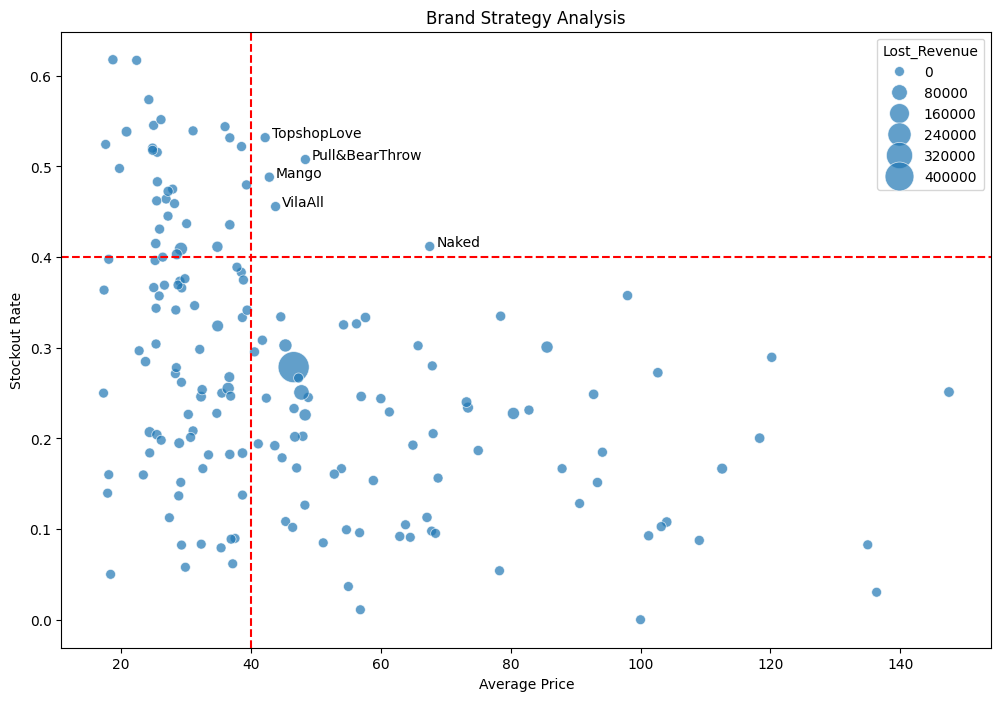

In [11]:
# STEP 05: SUMMARIZING INSIGHTS AND NEXT STEPS

# Aggregating data and potentially getting some strategic advice on the different brands.

brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count'

 }).reset_index()

# If a brand only list maybe just 2 items that we're not focus right now
brand_strategy = brand_strategy[brand_strategy['name'] > 10]

# Creating Visualization for Brand Strategy Analysis
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size='Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7,
    palette='virdis'
)

winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['Brand']
    )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')



In [ ]:
# STEP 06: INTERPRETING THE BRAND STRATEGY SCATTER PLOT

# 1. Most of our inventory is clustered in the low price and low demand type of the chart.
# 2. It's a safe area but low growth potentially.
# 3. The red line reveal a bit of a outlier group.
# 4. The top right quadrant is a brands that the customers are willing to pay a bit of a premium.
# 5 this is the kind of the higher price of this trend and selling out faster.
# 6. These brands can restock them and given by the very high stockout rate.
# 7. These brands like Mango, Pulandar, Topshop is seems to be kind of gold mine of ASOS based on the whole analysis.
# 8. even at a higher price, customers they are still buying them very frequently.
# 9. They are keep losing money day-by-day because these items are getting out of stock in a very early.
# 10. strategic tools for these brands is to double down on especially these specific stocks due to high value that can be taken from these brands.
# 11. the other parts of the quadrant, the top left might be low price but still in high demand.
# 12. the items that constantly need and buy at a lower price, still high demand.
# 13. bottom right quadrant, brands with high price but potentially but not a very high demands.
# 14. The website that might liquidate the items maybe to have in ASOS website
# 15. bottom left, low price = low demand type of products. we can reduce and not put on the website

In [ ]:
# STEP 07: FINAL RECOMMENDATIONS AND CONCLUSION

# 1. We are losing money due to the amount of loss revenue
# 2. Sum the top 5 brands up and focus on the top right quadrant of the analysis 
# 3. Try to re-allocate budget from the underperforming from bottom right and secure inventory for the high demand winners